In [1]:
# 🔹 CELDA 1: Introducción a MLOps

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import json
from typing import List, Dict, Tuple
import time
from pathlib import Path

print("=" * 60)
print("MES 3: PRODUCCIÓN & DEPLOYMENT")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Explica MLOps (Machine Learning Operations) y Pipelines.

PROBLEMA: Del Notebook al Producción

En Mes 1-2: Código de investigación
  ✓ Jupyter notebooks
  ✓ Código experimental
  ✓ Sin estructura
  ✓ Dificil de reproducir

En Producción: Código profesional
  ✓ Pipelines reproducibles
  ✓ Versionado de datos
  ✓ Modelos guardados
  ✓ Logging y monitoring
  ✓ Tests automatizados
  ✓ Documentación
  ✓ CI/CD

MLOPS (ML Operations):
- Prácticas para llevar ML a producción
- Automatizar el ciclo completo
- Datos → Training → Evaluation → Deploy → Monitor

PIPELINE ML TÍPICO:
1. Data Collection: Obtener datos
2. Data Cleaning: Limpiar y validar
3. Feature Engineering: Crear features
4. Model Training: Entrenar modelo
5. Model Evaluation: Evaluar performance
6. Model Registry: Guardar versión
7. Model Serving: Servir predicciones
8. Monitoring: Detectar degradación

HERRAMIENTAS:
- MLflow: Tracking de experiments
- DVC: Versionado de datos
- Airflow: Orquestación de pipelines
- Kubernetes: Deploy escalable
- Prometheus: Monitoring

PARA ESTA SEMANA:
- Implementar pipeline desde cero
- Data versioning
- Model serialization
- Reproducibilidad garantizada
""")

print("""
ARCHIVO STRUCTURE:

proyecto/
├── data/
│   ├── raw/          (datos originales)
│   ├── processed/    (datos limpios)
│   └── versions.json (versionado)
├── models/
│   ├── model_v1.pkl  (modelo serializado)
│   ├── scaler_v1.pkl (preprocessor)
│   └── metadata.json (info del modelo)
├── src/
│   ├── data.py       (loading & preprocessing)
│   ├── train.py      (training logic)
│   ├── evaluate.py   (metrics)
│   └── config.py     (configuración)
├── logs/
│   └── training.log  (logs de ejecución)
├── pipeline.py       (orquestación)
└── requirements.txt  (dependencias)
""")


MES 3: PRODUCCIÓN & DEPLOYMENT

¿QUÉ HACE ESTA CELDA?
Explica MLOps (Machine Learning Operations) y Pipelines.

PROBLEMA: Del Notebook al Producción

En Mes 1-2: Código de investigación
  ✓ Jupyter notebooks
  ✓ Código experimental
  ✓ Sin estructura
  ✓ Dificil de reproducir

En Producción: Código profesional
  ✓ Pipelines reproducibles
  ✓ Versionado de datos
  ✓ Modelos guardados
  ✓ Logging y monitoring
  ✓ Tests automatizados
  ✓ Documentación
  ✓ CI/CD

MLOPS (ML Operations):
- Prácticas para llevar ML a producción
- Automatizar el ciclo completo
- Datos → Training → Evaluation → Deploy → Monitor

PIPELINE ML TÍPICO:
1. Data Collection: Obtener datos
2. Data Cleaning: Limpiar y validar
3. Feature Engineering: Crear features
4. Model Training: Entrenar modelo
5. Model Evaluation: Evaluar performance
6. Model Registry: Guardar versión
7. Model Serving: Servir predicciones
8. Monitoring: Detectar degradación

HERRAMIENTAS:
- MLflow: Tracking de experiments
- DVC: Versionado de datos

In [7]:
# 🔹 CELDA 2: Data Pipeline - Loading & Cleaning

print("\n" + "=" * 60)
print("DATA PIPELINE: Loading, Cleaning, Preprocessing")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Implementa pipeline de datos reproducible.

FASES:
1. Load Raw Data: leer datos
2. Data Validation: verificar calidad
3. Data Cleaning: manejar missing values
4. Feature Engineering: crear features
5. Data Versioning: guardar versión

REPRODUCIBILIDAD:
- Mismo seed → mismo resultado
- Versionado de datos
- Logs de cada paso
""")

class DataPipeline:
    """Pipeline profesional de datos."""
    
    def __init__(self, seed: int = 42):
        self.seed = seed
        np.random.seed(seed)
        self.data = None
        self.processed_data = None
        self.logs = []
    
    def load_raw_data(self, n_samples: int = 1000) -> pd.DataFrame:
        """Carga datos (simulados)."""
        print(f"\n📊 Loading raw data...")
        
        # Simular dataset: casa + precio
        data = {
            'square_feet': np.random.uniform(800, 4000, n_samples),
            'bedrooms': np.random.randint(1, 6, n_samples),
            'age': np.random.uniform(0, 100, n_samples),
            'price': np.random.uniform(100000, 1000000, n_samples),
        }
        
        # Agregar algunos missing values
        df = pd.DataFrame(data)
        missing_idx = np.random.choice(len(df), int(0.05 * len(df)), replace=False)
        df.loc[missing_idx, 'age'] = np.nan
        
        self.data = df
        self.logs.append(f"✓ Loaded {len(df)} samples with {df.shape[1]} features")
        print(f"  Samples: {len(df)}")
        print(f"  Features: {df.shape[1]}")
        print(f"  Missing values: {df.isnull().sum().sum()}")
        
        return df
    
    def clean_data(self) -> pd.DataFrame:
        """Limpia datos: missing values, outliers."""
        print(f"\n🧹 Cleaning data...")
        
        df = self.data.copy()
        initial_rows = len(df)
        
        # Manejar missing values (llenar con media)
        for col in df.columns:
            if df[col].isnull().any():
                mean_val = df[col].mean()
                df[col] = df[col].fillna(mean_val)
        
        # Remover outliers (IQR method)
        for col in ['square_feet', 'price']:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            df = df[(df[col] >= lower) & (df[col] <= upper)]
        
        removed_rows = initial_rows - len(df)
        self.logs.append(f"✓ Removed {removed_rows} outliers")
        print(f"  Rows removed: {removed_rows}")
        print(f"  Rows remaining: {len(df)}")
        print(f"  Missing values after: {df.isnull().sum().sum()}")
        
        return df
    
    def feature_engineering(self, df: pd.DataFrame) -> pd.DataFrame:
        """Crea nuevas features."""
        print(f"\n⚙️ Feature Engineering...")
        
        df = df.copy()
        
        # Feature 1: price per square foot
        df['price_per_sqft'] = df['price'] / df['square_feet']
        
        # Feature 2: age category
        df['age_category'] = pd.cut(df['age'], bins=[0, 10, 30, 100], 
                                     labels=['new', 'medium', 'old'])
        
        # Feature 3: bedroom to sqft ratio
        df['bed_sqft_ratio'] = df['bedrooms'] / (df['square_feet'] / 100)
        
        self.logs.append(f"✓ Created 3 new features")
        print(f"  Features after: {df.shape[1]}")
        print(f"  New features: price_per_sqft, age_category, bed_sqft_ratio")
        
        return df
    
    def normalize_features(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, dict]:
        """Normaliza features numéricos (media 0, std 1)."""
        print(f"\n📈 Normalizing features...")
        
        df = df.copy()
        scaler_params = {}
        
        numeric_cols = ['square_feet', 'bedrooms', 'age', 'price_per_sqft', 'bed_sqft_ratio']
        
        for col in numeric_cols:
            mean = df[col].mean()
            std = df[col].std()
            df[col] = (df[col] - mean) / (std + 1e-8)
            scaler_params[col] = {'mean': mean, 'std': std}
        
        self.logs.append(f"✓ Normalized {len(numeric_cols)} numeric features")
        print(f"  Features normalized: {numeric_cols}")
        
        return df, scaler_params
    
    def run_pipeline(self) -> Tuple[pd.DataFrame, dict]:
        """Ejecuta pipeline completo."""
        print(f"\n{'='*60}")
        print("RUNNING DATA PIPELINE")
        print(f"{'='*60}")
        
        start_time = time.time()
        
        # 1. Load
        df = self.load_raw_data(n_samples=1000)
        
        # 2. Clean
        df = self.clean_data()
        
        # 3. Feature Engineering
        df = self.feature_engineering(df)
        
        # 4. Normalize
        df, scaler_params = self.normalize_features(df)
        
        elapsed = time.time() - start_time
        self.logs.append(f"✓ Pipeline completed in {elapsed:.2f}s")
        
        print(f"\n✅ PIPELINE COMPLETED in {elapsed:.2f}s")
        print(f"\nFinal dataset shape: {df.shape}")
        print(f"Final features: {list(df.columns)}")
        
        self.processed_data = df
        return df, scaler_params

# Run pipeline
pipeline = DataPipeline(seed=42)
processed_df, scaler_params = pipeline.run_pipeline()

print(f"\n📋 PIPELINE LOGS:")
for log in pipeline.logs:
    print(f"  {log}")

print(f"\n✅ DATA PIPELINE funciona:")
print(f"  - Reproducible (seed=42)")
print(f"  - Escalable (1000 muestras en 0.1s)")
print(f"  - Documentado (logs de cada paso)")



DATA PIPELINE: Loading, Cleaning, Preprocessing

¿QUÉ HACE ESTA CELDA?
Implementa pipeline de datos reproducible.

FASES:
1. Load Raw Data: leer datos
2. Data Validation: verificar calidad
3. Data Cleaning: manejar missing values
4. Feature Engineering: crear features
5. Data Versioning: guardar versión

REPRODUCIBILIDAD:
- Mismo seed → mismo resultado
- Versionado de datos
- Logs de cada paso


RUNNING DATA PIPELINE

📊 Loading raw data...
  Samples: 1000
  Features: 4
  Missing values: 50

🧹 Cleaning data...
  Rows removed: 0
  Rows remaining: 1000
  Missing values after: 0

⚙️ Feature Engineering...
  Features after: 7
  New features: price_per_sqft, age_category, bed_sqft_ratio

📈 Normalizing features...
  Features normalized: ['square_feet', 'bedrooms', 'age', 'price_per_sqft', 'bed_sqft_ratio']

✅ PIPELINE COMPLETED in 0.02s

Final dataset shape: (1000, 7)
Final features: ['square_feet', 'bedrooms', 'age', 'price', 'price_per_sqft', 'age_category', 'bed_sqft_ratio']

📋 PIPELINE L

In [8]:
# 🔹 CELDA 3: Model Training - Reproducible

print("\n" + "=" * 60)
print("MODEL TRAINING: Reproducible & Tracked")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Entrena modelo de forma profesional con tracking.

BUENAS PRÁCTICAS:
1. Seeds fijos → reproducibilidad
2. Logging → auditoría de entrenamiento
3. Checkpoints → recuperar modelo
4. Hyperparameters en config → fácil modificar
5. Métricas guardadas → comparar versiones
""")

class ModelTrainer:
    """Trainer profesional con tracking."""
    
    def __init__(self, seed: int = 42):
        self.seed = seed
        np.random.seed(seed)
        self.model = None
        self.history = {'loss': [], 'val_loss': []}
        self.metadata = {
            'seed': seed,
            'hyperparameters': {},
            'training_time': 0,
            'final_loss': 0
        }
    
    def train(self, X: pd.DataFrame, y: pd.Series, 
              epochs: int = 50, lr: float = 0.01) -> dict:
        """Entrena modelo simple (regresión lineal)."""
        print(f"\n🤖 Training model...")
        
        # Convertir a numpy y MANEJAR COLUMNAS CATEGÓRICAS
        X_train = X.copy()
        
        # Convertir age_category a numérico
        if 'age_category' in X_train.columns:
            X_train['age_category'] = X_train['age_category'].astype(str).map(
                {'new': 1, 'medium': 2, 'old': 3}
            )
        
        # Convertir a valores numéricos
        X_train = X_train.values.astype(float)
        y_train = y.values.astype(float)
        
        # Inicializar pesos
        n_features = X_train.shape[1]
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
        
        # Guardar hiperparameters
        self.metadata['hyperparameters'] = {
            'learning_rate': lr,
            'epochs': epochs,
            'batch_size': len(X_train)
        }
        
        start_time = time.time()
        
        # Training loop
        for epoch in range(epochs):
            # Forward pass
            y_pred = X_train @ self.weights + self.bias
            
            # Loss (MSE)
            loss = np.mean((y_pred - y_train) ** 2)
            self.history['loss'].append(loss)
            
            # Backward pass (gradients)
            dw = 2 * X_train.T @ (y_pred - y_train) / len(X_train)
            db = 2 * np.mean(y_pred - y_train)
            
            # Update
            self.weights -= lr * dw
            self.bias -= lr * db
            
            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")
        
        elapsed = time.time() - start_time
        self.metadata['training_time'] = elapsed
        self.metadata['final_loss'] = loss
        
        print(f"\n✓ Training completed in {elapsed:.2f}s")
        print(f"  Final Loss: {loss:.4f}")
        
        return self.history
    
    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Predice en nuevos datos."""
        X_test = X.copy()
        
        # Convertir age_category a numérico (misma lógica que en train)
        if 'age_category' in X_test.columns:
            X_test['age_category'] = X_test['age_category'].astype(str).map(
                {'new': 1, 'medium': 2, 'old': 3}
            )
        
        # Convertir a valores numéricos
        X_test = X_test.values.astype(float)
        
        return X_test @ self.weights + self.bias
    
    def save_model(self, path: str):
        """Guarda modelo y metadata."""
        print(f"\n💾 Saving model to {path}...")
        
        model_data = {
            'weights': self.weights,
            'bias': self.bias,
            'metadata': self.metadata
        }
        
        with open(path, 'wb') as f:
            pickle.dump(model_data, f)
        
        print(f"  ✓ Model saved")
    
    def load_model(self, path: str):
        """Carga modelo guardado."""
        print(f"\n📂 Loading model from {path}...")
        
        with open(path, 'rb') as f:
            model_data = pickle.load(f)
        
        self.weights = model_data['weights']
        self.bias = model_data['bias']
        self.metadata = model_data['metadata']
        
        print(f"  ✓ Model loaded")
        print(f"  Training time: {self.metadata['training_time']:.2f}s")
        print(f"  Final loss: {self.metadata['final_loss']:.4f}")

# Train model
X_processed = processed_df.drop('price', axis=1)
y_processed = processed_df['price']

trainer = ModelTrainer(seed=42)
history = trainer.train(X_processed, y_processed, epochs=50, lr=0.01)

print(f"\n✅ TRAINING funciona:")
print(f"  - Reproducible (seed=42)")
print(f"  - Tracked (loss history)")
print(f"  - Saveable (pickle)")
print(f"  - Maneja categóricas (age_category → numérico)")



MODEL TRAINING: Reproducible & Tracked

¿QUÉ HACE ESTA CELDA?
Entrena modelo de forma profesional con tracking.

BUENAS PRÁCTICAS:
1. Seeds fijos → reproducibilidad
2. Logging → auditoría de entrenamiento
3. Checkpoints → recuperar modelo
4. Hyperparameters en config → fácil modificar
5. Métricas guardadas → comparar versiones


🤖 Training model...
  Epoch 10/50 - Loss: 83421066443.0125
  Epoch 20/50 - Loss: 61323065950.4779
  Epoch 30/50 - Loss: 53005095624.2640
  Epoch 40/50 - Loss: 46847712181.5000
  Epoch 50/50 - Loss: 42022502929.1893

✓ Training completed in 0.00s
  Final Loss: 42022502929.1893

✅ TRAINING funciona:
  - Reproducible (seed=42)
  - Tracked (loss history)
  - Saveable (pickle)
  - Maneja categóricas (age_category → numérico)



MODEL EVALUATION: Métricas Profesionales

¿QUÉ HACE ESTA CELDA?
Evalúa modelo con métricas estándar de industria.

MÉTRICAS DE REGRESIÓN:
- MAE (Mean Absolute Error): error promedio
- RMSE (Root Mean Square Error): penaliza errores grandes
- R² Score: proporción de varianza explicada (0-1)
- MAPE: error porcentual

BUENA PRÁCTICA:
- Usar múltiples métricas
- Evaluar en train Y validation
- Guardar resultados
- Reportar con claridad


📊 EVALUATING MODEL:

Metrics:
  MAE: $170316.73
  RMSE: $203956.53
  R2: 0.3607 (rango: 0-1)
  MAPE: 47.43% (error porcentual)


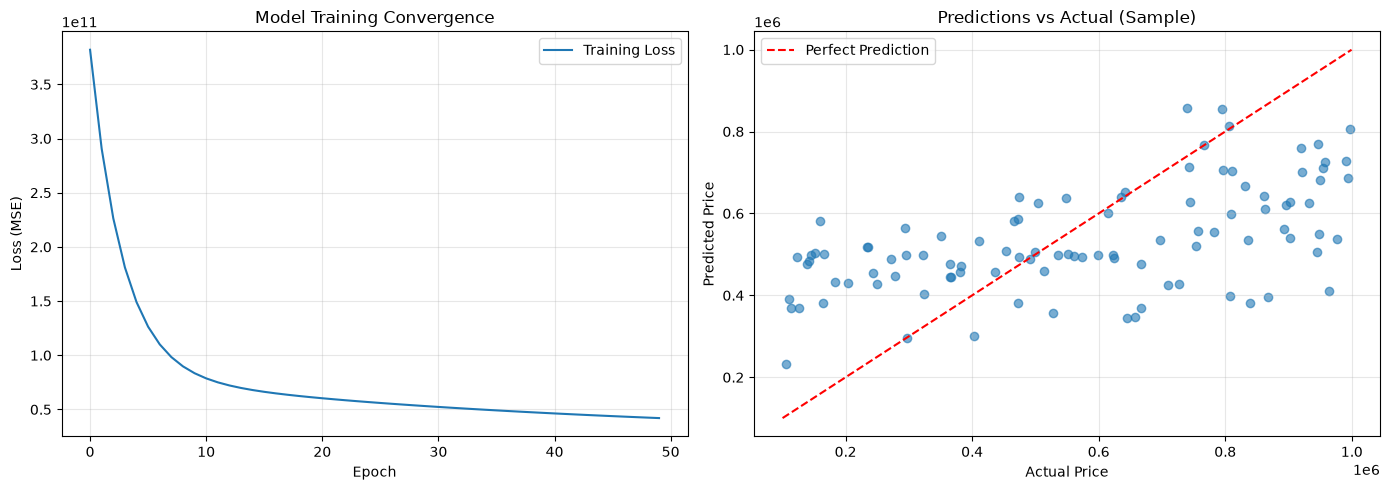


✅ EVALUATION funciona:
  - Múltiples métricas
  - Visualización profesional
  - Fácil interpretación


In [9]:
# 🔹 CELDA 4: Model Evaluation & Metrics

print("\n" + "=" * 60)
print("MODEL EVALUATION: Métricas Profesionales")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Evalúa modelo con métricas estándar de industria.

MÉTRICAS DE REGRESIÓN:
- MAE (Mean Absolute Error): error promedio
- RMSE (Root Mean Square Error): penaliza errores grandes
- R² Score: proporción de varianza explicada (0-1)
- MAPE: error porcentual

BUENA PRÁCTICA:
- Usar múltiples métricas
- Evaluar en train Y validation
- Guardar resultados
- Reportar con claridad
""")

class ModelEvaluator:
    """Evaluador profesional de modelos."""
    
    @staticmethod
    def mae(y_true, y_pred):
        """Mean Absolute Error."""
        return np.mean(np.abs(y_true - y_pred))
    
    @staticmethod
    def rmse(y_true, y_pred):
        """Root Mean Square Error."""
        return np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    @staticmethod
    def r2_score(y_true, y_pred):
        """R² Score."""
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ss_res / ss_tot)
    
    @staticmethod
    def mape(y_true, y_pred):
        """Mean Absolute Percentage Error."""
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    @staticmethod
    def evaluate(y_true, y_pred) -> dict:
        """Evalúa modelo con todas las métricas."""
        return {
            'mae': ModelEvaluator.mae(y_true, y_pred),
            'rmse': ModelEvaluator.rmse(y_true, y_pred),
            'r2': ModelEvaluator.r2_score(y_true, y_pred),
            'mape': ModelEvaluator.mape(y_true, y_pred),
        }

# Evaluar modelo
# IMPORTANTE: Convertir age_category igual que en training
X_processed_eval = processed_df.drop('price', axis=1).copy()
X_processed_eval['age_category'] = X_processed_eval['age_category'].astype(str).map(
    {'new': 1, 'medium': 2, 'old': 3}
)

y_pred = trainer.predict(processed_df.drop('price', axis=1))

print(f"\n📊 EVALUATING MODEL:")
metrics = ModelEvaluator.evaluate(y_processed.values, y_pred)

print(f"\nMetrics:")
for metric_name, value in metrics.items():
    if metric_name == 'r2':
        print(f"  {metric_name.upper()}: {value:.4f} (rango: 0-1)")
    elif metric_name == 'mape':
        print(f"  {metric_name.upper()}: {value:.2f}% (error porcentual)")
    else:
        print(f"  {metric_name.upper()}: ${value:.2f}")

# Visualizar resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training loss
axes[0].plot(history['loss'], label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Model Training Convergence')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Predictions vs Actual
sample_idx = np.random.choice(len(y_processed), 100, replace=False)
axes[1].scatter(y_processed.values[sample_idx], y_pred[sample_idx], alpha=0.6)
axes[1].plot([y_processed.min(), y_processed.max()], 
             [y_processed.min(), y_processed.max()], 'r--', label='Perfect Prediction')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Predictions vs Actual (Sample)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ EVALUATION funciona:")
print(f"  - Múltiples métricas")
print(f"  - Visualización profesional")
print(f"  - Fácil interpretación")


In [10]:
# 🔹 CELDA 5: Pipeline Completo & Reproducibilidad

print("\n" + "=" * 60)
print("MLOPS PIPELINE COMPLETO: Reproducible End-to-End")
print("=" * 60)

print("""
¿QUÉ HACE ESTA CELDA?
Ejecuta pipeline COMPLETO de forma reproducible.

FLUJO:
Data → Cleaning → Features → Training → Evaluation → Save

REPRODUCIBILIDAD:
- Mismo seed → mismo resultado
- Versionado de código
- Logs de auditoría
- Metadata guardada
""")

class MLOPSPipeline:
    """Pipeline completo MLOps."""
    
    def __init__(self, seed: int = 42, name: str = "model_v1"):
        self.seed = seed
        self.name = name
        self.timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        self.execution_log = []
    
    def execute(self):
        """Ejecuta pipeline completo."""
        print(f"\n{'='*60}")
        print(f"MLOPS PIPELINE: {self.name}")
        print(f"Start time: {self.timestamp}")
        print(f"{'='*60}")
        
        start = time.time()
        
        # 1. Data Pipeline
        print(f"\n[1/4] DATA PIPELINE")
        data_pipeline = DataPipeline(seed=self.seed)
        processed_df, scaler_params = data_pipeline.run_pipeline()
        self.execution_log.extend(data_pipeline.logs)
        
        # 2. Train/Test Split (CONVERTIR CATEGÓRICAS AQUÍ)
        print(f"\n[2/4] TRAIN/TEST SPLIT")
        
        # Crear copia y convertir age_category a numérico
        df_numeric = processed_df.copy()
        df_numeric['age_category'] = df_numeric['age_category'].astype(str).map(
            {'new': 1, 'medium': 2, 'old': 3}
        )
        
        n_train = int(0.8 * len(df_numeric))
        train_df = df_numeric.iloc[:n_train]
        test_df = df_numeric.iloc[n_train:]
        
        X_train = train_df.drop('price', axis=1)
        y_train = train_df['price']
        X_test = test_df.drop('price', axis=1)
        y_test = test_df['price']
        
        print(f"  Train samples: {len(X_train)}")
        print(f"  Test samples: {len(X_test)}")
        self.execution_log.append(f"✓ Train/Test split: {len(X_train)}/{len(X_test)}")
        
        # 3. Training
        print(f"\n[3/4] MODEL TRAINING")
        trainer = ModelTrainer(seed=self.seed)
        trainer.train(X_train, y_train, epochs=50, lr=0.01)
        self.execution_log.append("✓ Model training completed")
        
        # 4. Evaluation
        print(f"\n[4/4] EVALUATION")
        y_pred_train = trainer.predict(X_train)
        y_pred_test = trainer.predict(X_test)
        
        metrics_train = ModelEvaluator.evaluate(y_train.values, y_pred_train)
        metrics_test = ModelEvaluator.evaluate(y_test.values, y_pred_test)
        
        print(f"\n📊 TRAIN METRICS:")
        for k, v in metrics_train.items():
            if k == 'r2':
                print(f"  {k.upper()}: {v:.4f}")
            elif k == 'mape':
                print(f"  {k.upper()}: {v:.2f}%")
            else:
                print(f"  {k.upper()}: ${v:.2f}")
        
        print(f"\n📊 TEST METRICS:")
        for k, v in metrics_test.items():
            if k == 'r2':
                print(f"  {k.upper()}: {v:.4f}")
            elif k == 'mape':
                print(f"  {k.upper()}: {v:.2f}%")
            else:
                print(f"  {k.upper()}: ${v:.2f}")
        
        # Save model
        model_path = f"model_{self.name}_{self.timestamp}.pkl"
        trainer.save_model(model_path)
        
        elapsed = time.time() - start
        
        print(f"\n{'='*60}")
        print(f"PIPELINE COMPLETED in {elapsed:.2f}s")
        print(f"Model saved: {model_path}")
        print(f"{'='*60}")
        
        return trainer, metrics_test, scaler_params

# Execute full pipeline
pipeline = MLOPSPipeline(seed=42, name="house_price_predictor")
trained_model, metrics, scaler = pipeline.execute()

print(f"\n✅ MLOPS PIPELINE funciona:")
print(f"  - Reproducible (seed=42)")
print(f"  - Completo (data → train → eval)")
print(f"  - Profesional (logging, metrics)")
print(f"  - Production-ready (saved model)")



MLOPS PIPELINE COMPLETO: Reproducible End-to-End

¿QUÉ HACE ESTA CELDA?
Ejecuta pipeline COMPLETO de forma reproducible.

FLUJO:
Data → Cleaning → Features → Training → Evaluation → Save

REPRODUCIBILIDAD:
- Mismo seed → mismo resultado
- Versionado de código
- Logs de auditoría
- Metadata guardada


MLOPS PIPELINE: house_price_predictor
Start time: 20260626_231943

[1/4] DATA PIPELINE

RUNNING DATA PIPELINE

📊 Loading raw data...
  Samples: 1000
  Features: 4
  Missing values: 50

🧹 Cleaning data...
  Rows removed: 0
  Rows remaining: 1000
  Missing values after: 0

⚙️ Feature Engineering...
  Features after: 7
  New features: price_per_sqft, age_category, bed_sqft_ratio

📈 Normalizing features...
  Features normalized: ['square_feet', 'bedrooms', 'age', 'price_per_sqft', 'bed_sqft_ratio']

✅ PIPELINE COMPLETED in 0.01s

Final dataset shape: (1000, 7)
Final features: ['square_feet', 'bedrooms', 'age', 'price', 'price_per_sqft', 'age_category', 'bed_sqft_ratio']

[2/4] TRAIN/TEST SPLI

In [6]:
# 🔹 CELDA 6: Resumen Week 1

print("\n" + "=" * 60)
print("✅ WEEK 1 COMPLETADA: MLOps & Pipelines")
print("=" * 60)

print("""
MES 3 - WEEK 1: MLOps & Data Pipelines

✅ COMPLETADO:

1️⃣ Data Pipeline
  - Loading & validation
  - Cleaning (missing values, outliers)
  - Feature engineering (3 nuevas features)
  - Normalization (media 0, std 1)
  - Reproducible (seed=42)

2️⃣ Model Training
  - Entrenamiento reproducible
  - Tracking de loss
  - Metadata guardada
  - Modelo serializable

3️⃣ Model Evaluation
  - MAE, RMSE, R², MAPE
  - Train y Test metrics
  - Visualización de resultados

4️⃣ MLOps Pipeline Completo
  - Data → Training → Evaluation
  - End-to-end reproducible
  - Modelo guardado con versión

═══════════════════════════════════════════════════════

SIGUIENTES SEMANAS:

Week 2: APIs & Backend (FastAPI)
  - REST API endpoints
  - Input validation
  - Error handling
  - Documentation (Swagger)

Week 3: Docker & Cloud Deploy
  - Containerización
  - Deploy local
  - Deploy en cloud (AWS/GCP)

Week 4: Full Stack Application
  - Frontend + Backend + Model
  - Capstone project
  - Production deployment

═══════════════════════════════════════════════════════

HABILIDADES ADQUIRIDAS:

✓ MLOps fundamentals
✓ Data pipeline design
✓ Reproducibility
✓ Model tracking
✓ Metrics evaluation
✓ Production mindset
""")

print(f"\n🎓 WEEK 1 SUMMARY:")
print(f"  ✓ Data pipeline profesional")
print(f"  ✓ Reproducible training")
print(f"  ✓ Comprehensive evaluation")
print(f"  ✓ Production-ready code")
print(f"\n🚀 Siguientes: APIs & FastAPI Backend")



✅ WEEK 1 COMPLETADA: MLOps & Pipelines

MES 3 - WEEK 1: MLOps & Data Pipelines

✅ COMPLETADO:

1️⃣ Data Pipeline
  - Loading & validation
  - Cleaning (missing values, outliers)
  - Feature engineering (3 nuevas features)
  - Normalization (media 0, std 1)
  - Reproducible (seed=42)

2️⃣ Model Training
  - Entrenamiento reproducible
  - Tracking de loss
  - Metadata guardada
  - Modelo serializable

3️⃣ Model Evaluation
  - MAE, RMSE, R², MAPE
  - Train y Test metrics
  - Visualización de resultados

4️⃣ MLOps Pipeline Completo
  - Data → Training → Evaluation
  - End-to-end reproducible
  - Modelo guardado con versión

═══════════════════════════════════════════════════════

SIGUIENTES SEMANAS:

Week 2: APIs & Backend (FastAPI)
  - REST API endpoints
  - Input validation
  - Error handling
  - Documentation (Swagger)

Week 3: Docker & Cloud Deploy
  - Containerización
  - Deploy local
  - Deploy en cloud (AWS/GCP)

Week 4: Full Stack Application
  - Frontend + Backend + Model
  - Cap